In [95]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

import warnings

warnings.filterwarnings("error", category=UserWarning)
warnings.filterwarnings("error", category=RuntimeWarning)

# Driedimensionale stroming in een halfoneindige ruimte met uniforme doorlatendheid

De stroming is naar een onttrekking $Q$ in punt (0,0,0). Verder is er achtergrondstroming $v$ in de negatieve x-richting. Bij onttrekking in (0,0,0) ontstaat uiteindelijk een een doorsnede
van een halve cirkel met radius b, waarbinnen hal het water door de onttrekking wordt opgeslokt. Kiezen we $b$ dan geldt voor de verhouding $v/Q$ het volgende

$$v_{\infty} = \frac {2 Q} {\pi b^2}$$

Voor kleinere $x$ kan $b_x$ verkregen worden door integratie

$$q_x = -\frac {Q}{4 \pi k} \frac{x}{r^2} - v_x$$

De grens (radius $\rho$) van het intrekgebied op afstand x van het onttrekkingspunt wordt verkrgen door integratie over de halve cirkel

$$Q = \pi \intop_0^{r_x} q_x \rho d\rho$$

Het recher lid is een van de $r_x$ die wordt gezocht. Analytisch is dit lastig, numeriek een stuk minder omdat de $q_x$ gemakkelijk op alle punten van een ruimtelijk
grid kan worden berekend en dus langs gridlijnen loodrecht op $x$ kan worden geïntegreerd waarna het $r_x$ door interpolatie kan worden bepaald.


In [170]:
class FlowField:
    
    def __init__(self, x0=0., y0=0., z0=0., Q=None, q=(0., 0., 0.), k=1., r0=0.2, por=0.333):
        self.Q = Q
        self.q = q
        self.k = k
        self.por = por
        self.r0 = r0
        
        self.x0, self.y0, self.z0 = np.array([x0, y0, z0])        
    
    
    def phi(self, x, y, z):
        """Return head at all grid points."""
        r = np.sqrt((x-self.x0) ** 2 + (y - self.y0) ** 2 + (z - self.z0) ** 2)
        r = np.maximum(r, self.r0)
        return -self.Q / (4 * np.pi * self.k * r) - (
            self.q[0] / self.k * (x - self.x0) -
            self.q[1] / self.k * (y - self.y0) -
            self.q[2] / self.k * (z - self.z0)
        )
    
    def flux(self, x, y, z):
        """Return 3 component flux vector on every grid point."""
        r = np.sqrt((x-self.x0) ** 2 + (y - self.y0) ** 2 + (z - self.z0) ** 2)
        r = np.maximum(r, self.r0) 
        kappa = -self.Q / (4 * np.pi * r**3)
        return (
            kappa * (x - self.x0) + self.q[0],
            kappa * (y - self.y0) + self.q[1],
            kappa * (z - self.z0) + self.q[2]
        )
    
    def velocity(self, x, y, z):
        """Return 3-component velocity."""
        r = np.sqrt((x - self.x0) ** 2 + (y - self.y0) ** 2 + (z - self.z0) ** 2)
        kappa = -self.Q / (4 * np.pi * r**3)
        qx = (kappa * (x - self.x0) + self.q[0]) / self.por
        qy = (kappa * (y - self.y0) + self.q[1]) / self.por
        qz = (kappa * (z - self.z0) + self.q[2]) / self.por
        return qx, qy, qz

   
# === Setup to compute stream lines using solve_ivp
def f(t, xyz, flow):
    x, y, z = xyz
    qx, qy, qz = flow.velocity(x, y, z)
    return [qx, qy, qz]

def hit_screen(t, xyz, flow):
    x, y, z = xyz
    r = np.sqrt(x*x + y*y + z*z)
    return r-flow.r0

hit_screen.terminal = True
hit_screen.direction = -1

def RK45(xyz, tmax, flow):
    x0, y0, z0 = xyz
    sol = solve_ivp(
        f,
        t_span=(0, tmax),
        y0=[x0, y0, z0],
        method='RK45',
        events = hit_screen,
        dense_output=True,
        max_step=0.1,
        args=(flow,),
    )
    tplot = np.linspace(sol.t[0], sol.t[-1], 100)
    xyz_plot = sol.sol(tplot)
    return tplot, xyz_plot


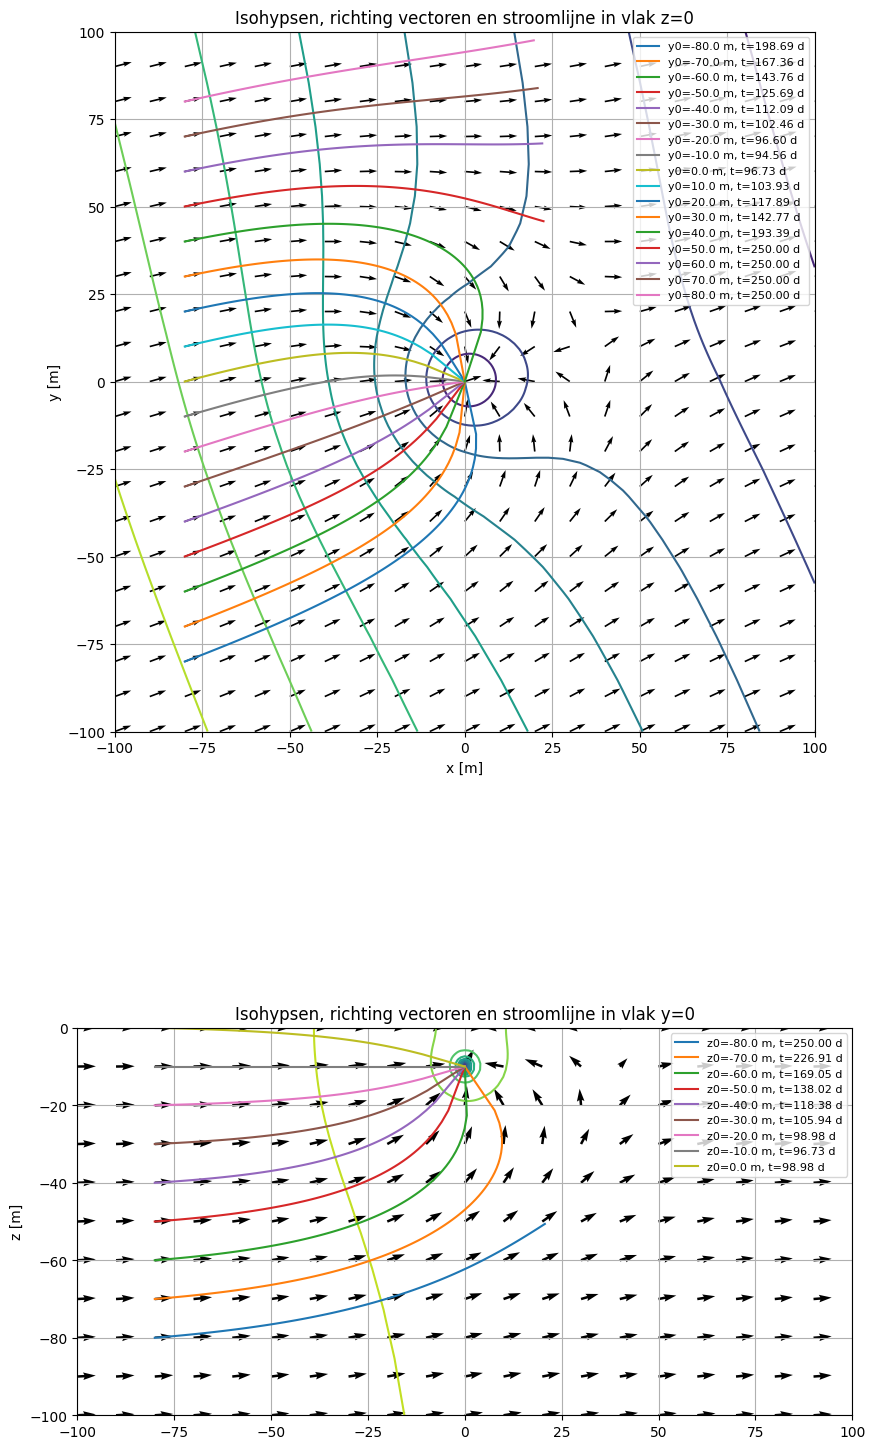

In [178]:
x1 = np.unique(np.hstack((0., np.logspace(0, 2, 30), -np.logspace(0, 2, 30))))
y1 = np.unique(np.hstack((0., np.logspace(0, 2, 30), -np.logspace(0, 2, 30))))[::-1]
z1 = np.unique(np.hstack((0, -np.logspace(0, 2, 30))))[::-1]

Z1, Y1, X1 = np.meshgrid(z1, y1, x1, indexing='ij')

x2 = np.arange(-100.,  201.,  10.)
y2 = np.arange( 100., -101., -10.)
z2 = np.arange(   0., -101., -10.)

Z2, Y2, X2 = np.meshgrid(z2, y2, x2, indexing='ij')

x0, y0, z0, r0 = 0., 0., -10., 0.2

Q = 2500
k = 1
b = 50.
tmax = 250.
vx = (2 / np.pi) * (Q / b**2) / 5

flow        = FlowField(x0, y0, +z0, Q=Q, q=(vx, vx/3, 0.), k=k, r0=r0)
flow_mirror = FlowField(x0, y0, -z0, Q=Q, q=(vx, vx/3, 0.), k=k, r0=r0)


# --- The potential
phi        = flow.phi( X1, Y1, Z1) + flow_mirror.phi( X1, Y1, Z1)
phi = phi[:, ::-1, :]
qx, qy, qz = np.array(flow.flux(X2, Y2, Z2)) + np.array(flow_mirror.flux(X2, Y2, Z2))

# ==== FIGURE ========================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 20))
ax1.set_title("Isohypsen, richting vectoren en stroomlijne in vlak z=0")
ax2.set_title("Isohypsen, richting vectoren en stroomlijne in vlak y=0")
ax1.set(xlabel='x [m]', ylabel='y [m]')
ax2.set(ylabel='z [m]')

iy1 = np.searchsorted(Y1[0,:,0][::-1], 0.)
iy2 = np.searchsorted(Y2[0,:,0][::-1], 0.)

ax1.contour(X1[0], Y1[0], phi[0], levels=10)
ax2.contour(X1[:,iy1], Z1[:,iy1], phi[:,iy1], levels=10)

speed = np.sqrt(qx**2 + qy**2 + qz**2)
ax1.quiver(X2[0], Y2[0], qx[0]/speed[0], qy[0]/speed[0],
           angles='xy',
           scale_units='xy',
           scale=0.2
)

ax2.quiver(X2[:,iy2], Z2[:,iy2], qx[:,iy2]/speed[:,iy2], qz[:,iy2]/speed[:,iy2],
           angles='xy',
           scale_units='xy',
           scale=0.2
)

x0, z0 = -80.0, z0
for y0 in np.arange(-80., 81., 10): # np.linspace(-75, 75, 11):
    tplot, xyz_plot = RK45((x0, y0, z0), tmax, flow)
    ax1.plot(xyz_plot[0], xyz_plot[1], label=f'y0={y0} m, t={tplot[-1]:.2f} d')

x0, y0 = -80.0, 0.
for z0_ in np.arange(-80., 1., 10.): # np.linspace(-75, 75, 11):
    tplot, xyz_plot = RK45((x0, y0, z0_), tmax, flow)
    ax2.plot(xyz_plot[0], xyz_plot[2], label=f'z0={z0_} m, t={tplot[-1]:.2f} d')

xlim = (-100, 100)
ylim = (-100, 100)
ax1.set_xlim(xlim)
ax2.set_xlim(xlim)
ax1.set_ylim(ylim)

ax1.set_aspect('equal')
ax2.set_aspect('equal')
ax1.grid()
ax2.grid()
ax1.legend(fontsize=8)
ax2.legend(fontsize=8)
ax1.set_xlim(-100, 100)

plt.show()



In [129]:
Y1[0,:,0]

array([ 100.        ,   85.31678524,   72.78953844,   62.10169419,
         52.98316906,   45.20353656,   38.56620421,   32.90344562,
         28.07216204,   23.9502662 ,   20.43359718,   17.43328822,
         14.87352107,   12.68961003,   10.82636734,    9.23670857,
          7.88046282,    6.72335754,    5.73615251,    4.89390092,
          4.17531894,    3.56224789,    3.03919538,    2.5929438 ,
          2.21221629,    1.88739182,    1.61026203,    1.3738238 ,
          1.1721023 ,    1.        ,   -1.        ,   -1.1721023 ,
         -1.3738238 ,   -1.61026203,   -1.88739182,   -2.21221629,
         -2.5929438 ,   -3.03919538,   -3.56224789,   -4.17531894,
         -4.89390092,   -5.73615251,   -6.72335754,   -7.88046282,
         -9.23670857,  -10.82636734,  -12.68961003,  -14.87352107,
        -17.43328822,  -20.43359718,  -23.9502662 ,  -28.07216204,
        -32.90344562,  -38.56620421,  -45.20353656,  -52.98316906,
        -62.10169419,  -72.78953844,  -85.31678524, -100.     

In [161]:
z1

array([   0.        ,   -1.        ,   -1.1721023 ,   -1.3738238 ,
         -1.61026203,   -1.88739182,   -2.21221629,   -2.5929438 ,
         -3.03919538,   -3.56224789,   -4.17531894,   -4.89390092,
         -5.73615251,   -6.72335754,   -7.88046282,   -9.23670857,
        -10.82636734,  -12.68961003,  -14.87352107,  -17.43328822,
        -20.43359718,  -23.9502662 ,  -28.07216204,  -32.90344562,
        -38.56620421,  -45.20353656,  -52.98316906,  -62.10169419,
        -72.78953844,  -85.31678524, -100.        ])